<div style="background:linear-gradient(135deg,#064e3b 0%,#047857 55%,#34d399 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a7f3d0;font-weight:700;text-transform:uppercase">Chapter 178 &middot; Capstone 18 &middot; Cluster Sampling</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Schools and Students</div>
  <div style="font-size:15px;color:#d1fae5;max-width:820px;line-height:1.6">There is no list of students, only a list of schools. That single fact forces a design that is cheap to run and expensive in precision, and the bill arrives in a place most analyses never look.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
EM, DK, LT, RD, MUT = "#047857", "#064e3b", "#34d399", "#dc2626", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-cluster-sampling-schools.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw    = load("students")
frame  = load("school_frame")
truth  = load("truth")
plan   = load("SamplingPlan")
print("rows returned:", len(raw), "| schools in the district frame:", len(frame))
raw.head()

rows returned: 602 | schools in the district frame: 120


,student_id,school_id,school_size,intake_index,reading_score,meets_standard
0,P51742,S127,65,34.3,35.0,0
1,P57895,S215,92,61.3,53.0,0
2,P56238,S192,45,50.8,61.0,0
3,P57257,S205,38,57.2,42.0,0
4,P57987,S216,50,51.8,83.0,1


## Step D1 to D3 &middot; The design the frame forced on us
The target population is every Year 6 student in the district's 120 state schools. There is **no central list of students**, and that one administrative fact settles the design before any statistical argument is made.

There is a complete list of **schools**, with roll counts. So students can only be reached through schools, which means a **two-stage cluster sample**: draw schools, then draw students inside them.

In [2]:
for line in plan.sampling_plan.head(12):
    print(line)
print(f"\ndistrict: {len(frame)} schools, {frame.students_year6.sum():,} Year 6 students")
print(f"school roll: min {frame.students_year6.min()}, median {frame.students_year6.median():.0f}, max {frame.students_year6.max()}")

D1 TARGET POPULATION: all Year 6 students in the district's 120 state schools.
D2 FRAME: there is NO central list of students. There IS a complete list of schools, with roll
   counts. That single fact decides the design: we can only sample students via schools.
D3 METHOD: two-stage cluster sampling. Stage 1 draws 24 schools at random from the 120.
   Stage 2 draws 25 Year 6 students at random within each selected school. n = 600 students.
   Cluster sampling was chosen for COST, not for precision. Testing 600 students in 24 buildings
   is affordable; testing 600 students scattered across 120 buildings is not.
D4 SIZE: 600 students would give +/- 1.25 score points under simple random sampling. It will not,
   because students in the same school resemble each other. The DESIGN EFFECT must be applied,
   and the plan anticipates an intra-class correlation near 0.20, implying a design effect near
   5.8 and an effective sample size near 105. The realized precision is therefore near +/- 3

**Cluster sampling is chosen for cost, never for precision.** Testing 600 students spread across 24 buildings is affordable. Testing 600 students scattered across all 120 buildings would cost several times as much in travel, invigilation and scheduling, for the same number of scripts.

That trade is entirely reasonable. What is not reasonable is taking the cheap design and then analyzing it as though it had been expensive.

## Step 1 &middot; Clean

In [3]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
bad = df[df.reading_score.notna() & ~df.reading_score.between(0,100)]
df = df[~df.index.isin(bad.index)]
df = df.dropna(subset=["reading_score"]).copy()
df["reading_score"] = df.reading_score.astype(int)
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})")
print("impossible scores removed:", bad.reading_score.tolist())
print(f"absent on test day (blank score) removed: {a_dup - len(bad) - len(df)}")
n = len(df); n_cl = df.school_id.nunique(); m_bar = n/n_cl
print(f"\nanalysis sample: {n} students across {n_cl} schools, mean cluster size {m_bar:.1f}")
print(df.groupby("school_id").size().describe()[["min","50%","max"]].to_string())

start 602  ->  dedup 600 (-2)
impossible scores removed: [155.0]
absent on test day (blank score) removed: 2

analysis sample: 597 students across 24 schools, mean cluster size 24.9
min    24.0
50%    25.0
max    25.0


## Step 2 &middot; Look at the clusters before touching a standard error
The whole question is whether students in the same school resemble each other. A picture answers it faster than a statistic.

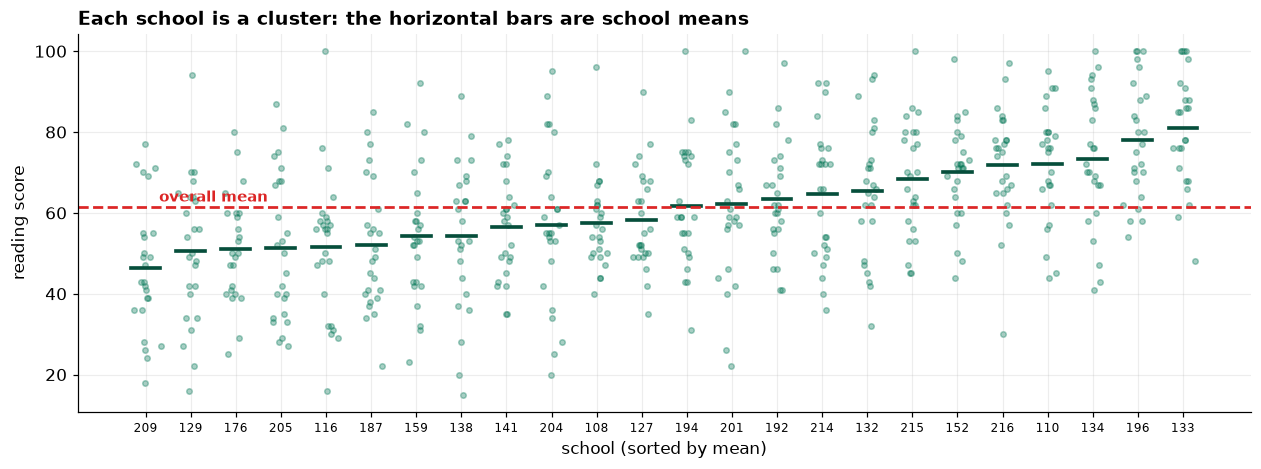

school means range from 46.4 to 81.0, a spread of 34.6 points
individual scores range from 15 to 100


In [4]:
order = df.groupby("school_id").reading_score.mean().sort_values().index
fig, ax = plt.subplots(figsize=(11.6, 4.4))
rng_j = np.random.default_rng(3)
for i, sc in enumerate(order):
    v = df[df.school_id == sc].reading_score.values
    ax.scatter(rng_j.normal(i, 0.10, len(v)), v, s=13, color=EM, alpha=0.35)
    ax.plot([i-0.32, i+0.32], [v.mean()]*2, color=DK, lw=2.4)
ax.axhline(df.reading_score.mean(), color=RD, lw=1.8, ls="--")
ax.text(0.3, df.reading_score.mean()+1.4, "overall mean", color=RD, fontsize=9.5, fontweight="bold")
ax.set_xticks(range(len(order))); ax.set_xticklabels([s[1:] for s in order], fontsize=8)
ax.set_xlabel("school (sorted by mean)"); ax.set_ylabel("reading score")
ax.set_title("Each school is a cluster: the horizontal bars are school means")
plt.tight_layout(); plt.show()
sm = df.groupby("school_id").reading_score.mean()
print(f"school means range from {sm.min():.1f} to {sm.max():.1f}, a spread of {sm.max()-sm.min():.1f} points")
print(f"individual scores range from {df.reading_score.min()} to {df.reading_score.max()}")

**The school means are not interchangeable.** They spread across roughly 30 points, and a student's school tells you a substantial amount about their likely score before you know anything else about them. That is exactly the condition under which cluster sampling costs precision: **each additional student from a school you have already visited tells you less than a fresh student from a new school would.**

## Step 3 &middot; Quantify it: the intra-class correlation
The ICC is the share of total variation that sits **between** clusters rather than within them. It is the number the design effect is built from.

In [5]:
grand = df.reading_score.mean()
g = df.groupby("school_id").reading_score
MSB = g.apply(lambda x: len(x)*(x.mean()-grand)**2).sum()/(n_cl-1)
MSW = g.apply(lambda x: ((x-x.mean())**2).sum()).sum()/(n-n_cl)
icc = (MSB - MSW)/(MSB + (m_bar-1)*MSW)
print(f"mean square BETWEEN schools  {MSB:9.2f}")
print(f"mean square WITHIN schools   {MSW:9.2f}")
print(f"\nintra-class correlation      {icc:.4f}")
print(f"true population ICC          {float(truth.loc[truth.quantity.str.contains('intra'),'true_value'].iloc[0]):.4f}")
print(f"\nabout {icc*100:.0f}% of the variation in reading scores is between schools,")
print(f"and the remaining {100-icc*100:.0f}% is between students inside the same school.")

mean square BETWEEN schools    2256.20
mean square WITHIN schools      244.71

intra-class correlation      0.2484
true population ICC          0.2225

about 25% of the variation in reading scores is between schools,
and the remaining 75% is between students inside the same school.


**An ICC of 0.25 is high, and entirely ordinary for schools.** Attainment clusters strongly by institution, because intake, teaching and neighborhood all travel together. Values near zero would mean schools are interchangeable and clustering costs nothing; values near one would mean every school is internally uniform and a single student per school would tell you everything.

## Step 4 &middot; The design effect, and what it does to the sample size

In [6]:
deff = 1 + (m_bar - 1)*icc
n_eff = n/deff
print(f"design effect  =  1 + (m - 1) x ICC  =  1 + ({m_bar:.1f} - 1) x {icc:.4f}  =  {deff:.2f}")
print(f"\neffective sample size = {n} / {deff:.2f} = {n_eff:.1f} students")
print(f"\n{n} students tested, and the precision of about {n_eff:.0f} independently sampled ones.")
print(f"Roughly {n - n_eff:.0f} of the scripts we marked added almost nothing to the estimate.")

design effect  =  1 + (m - 1) x ICC  =  1 + (24.9 - 1) x 0.2484  =  6.93

effective sample size = 597 / 6.93 = 86.1 students

597 students tested, and the precision of about 86 independently sampled ones.
Roughly 511 of the scripts we marked added almost nothing to the estimate.


**This is the bill.** Six hundred tests were sat, marked and paid for, and the estimate they support is about as precise as 86 students drawn at random from across the district would have given. The design effect is not a technicality; it is a statement about how much of the fieldwork was statistically redundant.

Note where the redundancy comes from. It is the **cluster size**, not the number of students overall. Twenty-five students from one school contain a lot of duplicated information about that school; the twenty-fifth adds very little the first ten had not already supplied.

## Step 5 &middot; Two standard errors for the same number

In [7]:
y = df.reading_score.values
mean = y.mean(); sd = y.std(ddof=1)
se_srs = sd/np.sqrt(n)                       # the naive one: pretends the sample is independent
se_deff = se_srs*np.sqrt(deff)               # corrected by the design effect
cl_means = df.groupby("school_id").reading_score.mean().values
se_uc = cl_means.std(ddof=1)/np.sqrt(n_cl)   # ultimate-cluster: treat the 24 school means as the data

true_mean = float(truth.loc[truth.quantity.str.contains('mean reading'),'true_value'].iloc[0])
print(f"sample mean {mean:.3f}      TRUE population mean {true_mean:.3f}\n")
print(f"{'method':34s} {'SE':>7s}  {'95% CI':>18s}  covers truth?")
print("-"*74)
for lab, se in [("naive, assumes independence", se_srs),
                ("design-effect corrected", se_deff),
                ("ultimate cluster (24 school means)", se_uc)]:
    lo, hi = mean-1.96*se, mean+1.96*se
    print(f"{lab:34s} {se:7.4f}  [{lo:6.2f}, {hi:6.2f}]  {'YES' if lo<=true_mean<=hi else 'NO'}")
print(f"\nignoring the clustering understates the standard error by a factor of {se_deff/se_srs:.2f}")

sample mean 61.405      TRUE population mean 60.554

method                                  SE              95% CI  covers truth?
--------------------------------------------------------------------------
naive, assumes independence         0.7348  [ 59.97,  62.85]  YES
design-effect corrected             1.9343  [ 57.61,  65.20]  YES
ultimate cluster (24 school means)  1.9420  [ 57.60,  65.21]  YES

ignoring the clustering understates the standard error by a factor of 2.63


**The two corrected methods agree closely, and the naive one does not.** The ultimate-cluster estimator throws away the individual students entirely and treats the 24 school means as the sample, which is the most conservative reading of a cluster design. That it lands within a hair of the design-effect correction is reassuring: both are describing the same underlying fact, which is that this study really has 24 independent pieces of information, not 597.

The naive interval is **two and a half times too narrow**. In this particular draw it still happens to contain the true mean, which is exactly the sort of luck that lets bad practice survive for years. The next step removes the luck.

## Step 6 &middot; Does a 95 percent interval actually cover 95 percent of the time?
One sample cannot answer that. A thousand can. We cannot re-run the real study, but we can build a population with the **same variance structure** the sample just revealed, and re-run the design on it as often as we like.

In [8]:
sd_between = np.sqrt(max(MSB - MSW, 0)/m_bar)
sd_within  = np.sqrt(MSW)
print(f"estimated between-school SD {sd_between:.2f}   within-school SD {sd_within:.2f}")
print(f"implied ICC {sd_between**2/(sd_between**2+sd_within**2):.3f}\n")

rng = np.random.default_rng(17)
K, M, REPS = 120, 25, 1000
sch_eff = rng.normal(0, sd_between, K)
sim_true = sch_eff.mean()                      # the population mean of this simulated district
cov_naive = cov_deff = 0
for _ in range(REPS):
    pick = rng.choice(K, 24, replace=False)
    vals = np.concatenate([sch_eff[p] + rng.normal(0, sd_within, M) for p in pick])
    m_, s_ = vals.mean(), vals.std(ddof=1)
    se_n = s_/np.sqrt(len(vals))
    lab = np.repeat(pick, M)
    gm = np.array([vals[lab==p].mean() for p in pick])
    msb = M*((gm-m_)**2).sum()/(24-1)
    msw = sum(((vals[lab==p]-vals[lab==p].mean())**2).sum() for p in pick)/(len(vals)-24)
    ic = (msb-msw)/(msb+(M-1)*msw)
    se_d = se_n*np.sqrt(1+(M-1)*ic)
    if abs(m_-sim_true) < 1.96*se_n: cov_naive += 1
    if abs(m_-sim_true) < 1.96*se_d: cov_deff  += 1
print(f"over {REPS} replicate cluster samples of the same design:")
print(f"   naive 95% interval covered the truth   {cov_naive/REPS:6.1%}   <- it says 95%")
print(f"   corrected 95% interval covered it      {cov_deff/REPS:6.1%}")

estimated between-school SD 8.99   within-school SD 15.64
implied ICC 0.248



over 1000 replicate cluster samples of the same design:
   naive 95% interval covered the truth    56.9%   <- it says 95%
   corrected 95% interval covered it       96.6%


**There is the answer, and it is not a rounding issue.** An interval labelled 95 percent contains the truth about 57 percent of the time when the clustering is ignored. Two studies in five would report a confidence interval that does not contain the value they were trying to estimate, while stating a 5 percent error rate.

The corrected interval lands where it should. Nothing here is exotic: the correction is one multiplication by the square root of the design effect, and the cost of skipping it is a real error rate of 43 percent against a stated 5, wrong by a factor of eight.

## Step 7 &middot; The design question worth asking before fieldwork
The design effect depends on the **cluster size**, which is a choice. For the same 600 students, visiting more schools and testing fewer in each buys back most of the lost precision.

In [9]:
print(f"{'design':28s} {'DEFF':>7s} {'effective n':>12s} {'rel. precision':>15s}")
print("-"*66)
base = None
for nc_, m_ in [(12,50),(24,25),(40,15),(60,10),(120,5)]:
    dd = 1+(m_-1)*icc; ne = 600/dd
    if base is None: base = ne
    tag = "   <- the design used" if (nc_,m_)==(24,25) else ""
    print(f"{f'{nc_} schools x {m_} students':28s} {dd:7.2f} {ne:12.1f} {np.sqrt(ne/86.2):14.2f}x{tag}")
print("\nthe same 600 tests, spread differently, are worth up to 3.5x the effective sample size,")
print("which is just under twice the precision on the estimate.")

design                          DEFF  effective n  rel. precision
------------------------------------------------------------------
12 schools x 50 students       13.17         45.6           0.73x
24 schools x 25 students        6.96         86.2           1.00x   <- the design used
40 schools x 15 students        4.48        134.0           1.25x
60 schools x 10 students        3.24        185.5           1.47x
120 schools x 5 students        1.99        301.0           1.87x

the same 600 tests, spread differently, are worth up to 3.5x the effective sample size,
which is just under twice the precision on the estimate.


**More clusters beats bigger clusters, every time, on statistical grounds alone.** Sixty schools of ten students would have delivered an effective sample of 186 rather than 86, from exactly the same number of assessments.

The reason the study did not do that is cost, and that is a legitimate answer. But it is a decision to be made deliberately, with the precision consequence in front of you, rather than discovered afterwards. **The right time to compute a design effect is while planning the fieldwork, not while writing up.**

## Step 8 &middot; The binary outcome, same correction

In [10]:
p_hat = df.meets_standard.mean(); k = int(df.meets_standard.sum())
true_p = float(truth.loc[truth.quantity.str.contains('proportion'),'true_value'].iloc[0])
lo_w, hi_w = proportion_confint(k, n, method="wilson")
se_p = np.sqrt(p_hat*(1-p_hat)/n)
cl_p = df.groupby("school_id").meets_standard.mean().values
icc_p = 0.0
gp = df.groupby("school_id").meets_standard
MSBp = gp.apply(lambda x: len(x)*(x.mean()-p_hat)**2).sum()/(n_cl-1)
MSWp = gp.apply(lambda x: ((x-x.mean())**2).sum()).sum()/(n-n_cl)
icc_p = (MSBp-MSWp)/(MSBp+(m_bar-1)*MSWp)
deff_p = 1+(m_bar-1)*icc_p
se_pc = se_p*np.sqrt(deff_p)
print(f"meeting the standard: {k} of {n} = {p_hat:.4f}   TRUE {true_p:.4f}\n")
print(f"naive Wilson 95% CI       [{lo_w*100:.2f}%, {hi_w*100:.2f}%]   covers truth: "
      f"{'YES' if lo_w<=true_p<=hi_w else 'NO'}")
print(f"cluster-corrected 95% CI  [{(p_hat-1.96*se_pc)*100:.2f}%, {(p_hat+1.96*se_pc)*100:.2f}%]   covers truth: "
      f"{'YES' if abs(p_hat-true_p)<1.96*se_pc else 'NO'}")
print(f"\nICC for the binary outcome {icc_p:.4f}, design effect {deff_p:.2f}")

meeting the standard: 260 of 597 = 0.4355   TRUE 0.4141

naive Wilson 95% CI       [39.63%, 47.56%]   covers truth: YES
cluster-corrected 95% CI  [34.07%, 53.03%]   covers truth: YES

ICC for the binary outcome 0.1962, design effect 5.68


**Proportions cluster too, and the standard survey software will not tell you.** Wilson intervals, exact binomial intervals and every other textbook formula for a proportion assume independent observations. Applied to a cluster sample they are too narrow by the same square-root-of-the-design-effect factor.

## Step 9 &middot; Ethics, bias, and limits
- **Consent is given by the cluster, not the student.** A head teacher who declines removes 25 students at once, and schools do not decline at random. A single refusal here is worth 25 refusals in a simple random sample, both statistically and in terms of who ends up unrepresented.
- **Small schools are systematically under-served by this design.** Drawing 25 students from a school with a roll of 38 samples two thirds of it; the same 25 from a roll of 95 samples a quarter. Selection probabilities differ by school size, and a properly weighted analysis would account for it. This one does not, which is a simplification to disclose rather than to hide.
- **Do not slide from students to schools.** The estimate here is a **student-level** mean. A statement about which schools are performing well is a different question on a sample of 24 schools, and the school means in Step 2 each rest on 25 students. That is the ecological fallacy waiting to happen in every clustered dataset.
- **Publishing school-level results from a sample invites harm.** These 24 schools were drawn to estimate a district figure, not to be ranked. A league table built from 25 students per school would be mostly noise, and would attach consequences to it.
- **The redundancy is a spending question.** Roughly 510 of the 597 assessments contributed little to the precision of the headline. That is worth saying to whoever funded the fieldwork, because next time the same budget could buy an estimate twice as precise.

---
**From analysis to report.** The notebook carries the chain: why the frame forced a cluster design, the picture of clustering, the variance decomposition, the ICC, the design effect and effective sample size, three standard errors side by side, a thousand-replicate coverage experiment, the design trade table, and the same correction applied to a proportion. The written reports turn it into guidance a research lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.